Step1: Load the data and clean it

In [2]:
#Step 1: Load the Data and Check Basic Information

import pandas as pd
#load the data
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\ROADMAP\DATA SCIENCE\after school\medical_appointment\archive (2)\KaggleV2-May-2016.csv")
# print(df.describe(include='all'))
print(df.shape) 
# print("\nFirst 5 rows: ")
# print(df.head())

print("\n Column names and data types")
print(df.info())

#Step 2: Data Cleaning and Type Conversion
df = df.rename(columns={
    'PatientId': 'patient_id',
    'AppointmentID': 'appointment_id',
    'Gender': 'gender',
    'ScheduledDay': 'scheduled_day',
    'AppointmentDay': 'appointment_day',
    'Age': 'age',
    'Neighbourhood': 'neighbourhood',
    'Scholarship': 'scholarship',
    'Hipertension': 'hypertension',
    'Diabetes': 'diabetes',
    'Alcoholism': 'alcoholism',
    'Handcap': 'handicap',
    'SMS_received': 'sms_received',
    'No-show': 'no_show'
})
# print("New column names: ")
# print(df.columns)

#Date conversion
df['scheduled_day'] = pd.to_datetime(df['scheduled_day']).dt.date
df['appointment_day'] = pd.to_datetime(df['appointment_day']).dt.date
# print(df['appointment_day'].head())
# print(df['scheduled_day'].head())

#Convert target column
# print(df['no_show'].value_counts(dropna=False))
# print(df['no_show'].unique())
df['no_show'] = df['no_show'].map({'Yes': 1, 'No':0})
# print(df['no_show'].head())

#Check if there's a duplicate row
print("Number of duplicated rows: ", df.duplicated().sum())

#Check how many people have negative ages
df.loc[df['age'] < 0, 'age'] = 0

#Convert gender to binary
df['gender'] = df['gender'].str.strip().str.upper()
# print(df['gender'].unique())
print(df['gender'].value_counts(dropna=False))
df['gender'] = df['gender'].map({'M': 0, 'F': 1})
# print(df['gender'].head())

df = df.drop(columns=['patient_id', 'appointment_id'], errors='ignore')

#Check if waiting days has a negative value
df['scheduled_day'] = pd.to_datetime(df['scheduled_day'])
df['appointment_day'] = pd.to_datetime(df['appointment_day'])
df['waiting_days'] = (df['appointment_day'] - df['scheduled_day']).dt.days
df = df[df['waiting_days'] >= 0]
df = df[df['waiting_days'] >= 0]
negative = (df['waiting_days'] < 0).sum()
# print(negative)

print((df['waiting_days'] < 0).any())

df['neighbourhood'] = df['neighbourhood'].astype('category')
# print(df[df['waiting_days'] > 90][['scheduled_day', 'appointment_day', 'waiting_days']].head())
print(df.describe())


(110527, 14)

 Column names and data types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB
None
Number of duplicated rows:  0
gender
F    

Step 2: Univariate analysis
We want to answer simple questions like:

    How many patients missed their appointment? (No-show rate)
    What is the age range of patients?
    Are there more males or females?
    How many patients have hypertension, diabetes, etc?

No show patients vs show patients
no_show
0    79.810354
1    20.189646
Name: proportion, dtype: float64

 Patients by age group: 
0              Senior
1              Senior
2              Senior
3               Child
4              Senior
             ...     
110522         Senior
110523         Senior
110524    Young Adult
110525          Adult
110526         Senior
Name: age_group, Length: 110522, dtype: category
Categories (5, object): ['Child' < 'Young Adult' < 'Adult' < 'Senior' < 'Elderly']

 gender
1    64.997919
0    35.002081
Name: proportion, dtype: float64

 hypertension
0    80.274515
1    19.725485
Name: proportion, dtype: float64

 diabetes
0    92.813196
1     7.186804
Name: proportion, dtype: float64

 alcoholism
0    96.959881
1     3.040119
Name: proportion, dtype: float64

 neighbourhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4430
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
TABUAZEIRO           31

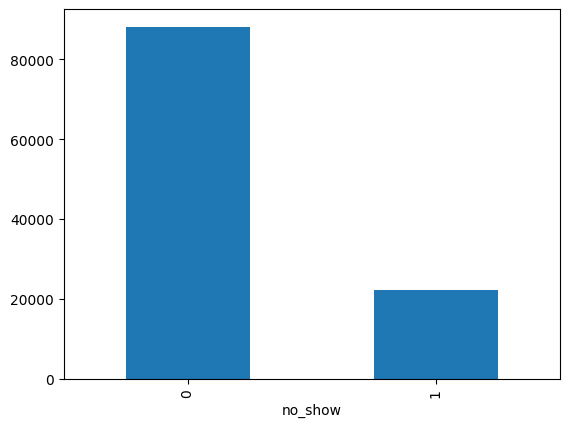

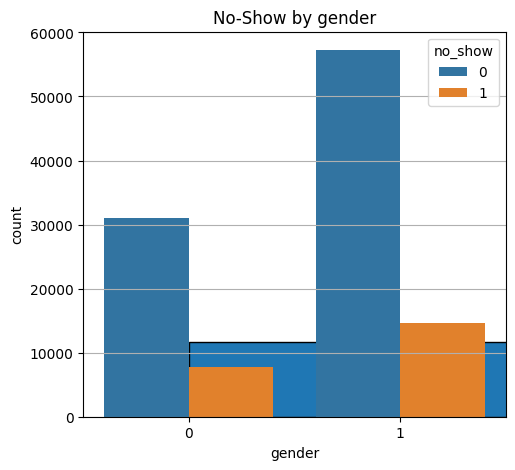

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

#1. What percentage of patients miss their appointment?
print("No show patients vs show patients")
print(df['no_show'].value_counts(normalize = True) * 100)
df['no_show'].value_counts().plot(kind='bar')

#2. Are most patients young, middle-aged, or old?
# print(df['age'].describe())
#set in groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 35, 50, 65, 120],
    labels=['Child', 'Young Adult', 'Adult', 'Senior', 'Elderly']
)
print("\n Patients by age group: ")
print(df['age_group'])
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
df['age'].hist(bins=20, edgecolor='black')
plt.title('Age Distribution')
#3. Do we have more female or male patients?
print("\n",df['gender'].value_counts(normalize=True)*100)

#4. How common are hypertension, diabetes, and alcoholism in this data?

disease_col = ['hypertension', 'diabetes', 'alcoholism']
for col in disease_col:
        print("\n", df[col].value_counts(normalize=True) * 100)

print("\n", df['neighbourhood'].value_counts().head(10))

print(df.groupby('gender')['no_show'].mean())
sns.countplot(x='gender', hue='no_show', data=df)
plt.title('No-Show by gender')
plt.show()


Step 4: Bivariate Analysis
We will answer questions like:

    Do males or females miss more?
    Do older or younger patients miss more?
    Does receiving SMS reduce no-shows?
    Do patients with hypertension or diabetes miss less?

No show rate by gender: 
gender
0    19.96381
1    20.31126
Name: no_show, dtype: float64


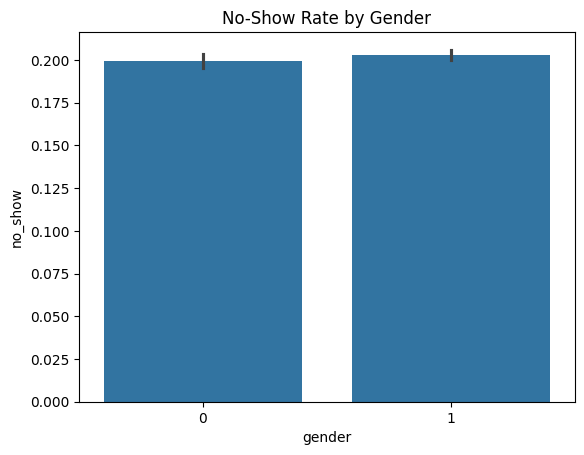


 No show by age group
age_group
Child(0-12)           20.959076
Teen(13-18)           26.053640
Young Adult(19-35)    23.828465
Adult(36-50)          20.322187
Senior(51-65)         16.549137
Elderly(66+)          15.526316
Name: no_show, dtype: float64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15376\136729612.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('age_group')['no_show'].mean()*100)


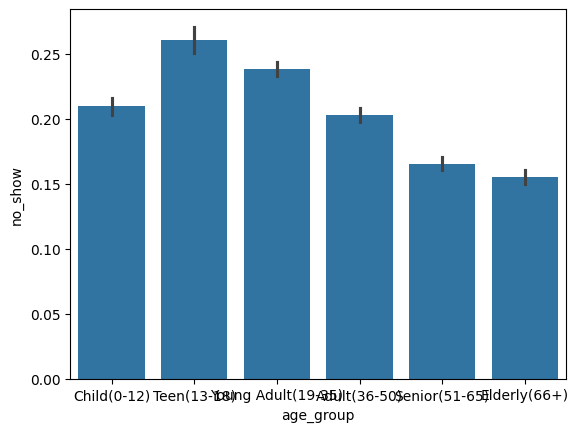

diabetes
0    20.358943
1    18.003273
Name: no_show, dtype: float64
hypertension
0    20.899223
1    17.301959
Name: no_show, dtype: float64
alcoholism
0    20.190926
1    20.148810
Name: no_show, dtype: float64
handicap
0    20.233093
1    17.843137
2    20.218579
3    23.076923
4    33.333333
Name: no_show, dtype: float64
scholarship
0    19.803133
1    23.736304
Name: no_show, dtype: float64


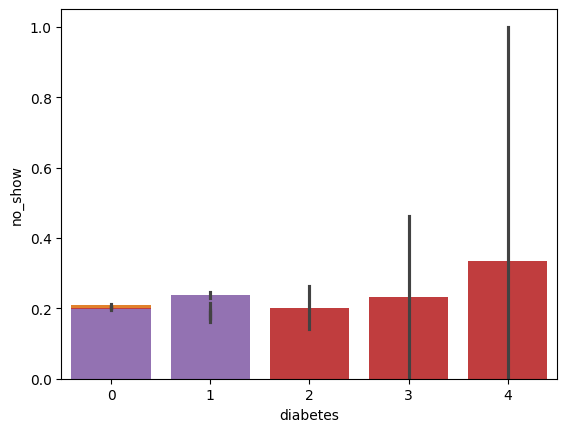

sms_received
0    16.697761
1    27.574545
Name: no_show, dtype: float64


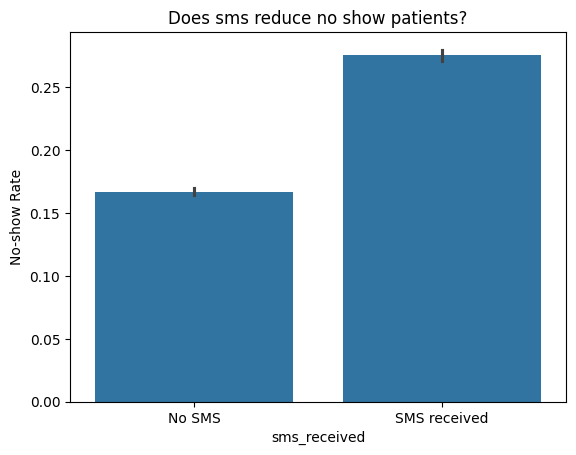

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#No-show rate by gender
print("No show rate by gender: ")
print(df.groupby('gender')['no_show'].mean() * 100)
sns.barplot(x='gender', y='no_show', data=df)
plt.title("No-Show Rate by Gender")
plt.show()

#No-show rate by age group
print("\n No show by age group")
df['age_group'] = pd.cut(df['age'],
                         bins=[0,12,18,35,50,65,120],
                         labels=['Child(0-12)', 'Teen(13-18)', 'Young Adult(19-35)',
                                 'Adult(36-50)', 'Senior(51-65)', 'Elderly(66+)'])
print(df.groupby('age_group')['no_show'].mean()*100)
sns.barplot(x='age_group', y='no_show', data=df)
plt.show()

#No-show rate by health conditions
health_cond = ['diabetes', 'hypertension', 'alcoholism', 'handicap', 'scholarship']
for col in health_cond:
    rate = df.groupby(col)['no_show'].mean()*100
    print(rate)
    sns.barplot(x=col, y='no_show', data=df)
plt.show()

#No show rate by sms received
print(df.groupby('sms_received')['no_show'].mean()*100)
plt.xticks(ticks=[0,1], labels=['No SMS', 'SMS received'])
sns.barplot(x='sms_received', y='no_show', data=df)
plt.title('Does sms reduce no show patients?')
plt.ylabel('No-show Rate')
plt.xlabel('sms_received')
plt.show()

Step 5: Missing Values, Outliers & New Features

Missing values in each column
gender                  0
scheduled_day           0
appointment_day         0
age                     0
neighbourhood           0
scholarship             0
hypertension            0
diabetes                0
alcoholism              0
handicap                0
sms_received            0
no_show                 0
waiting_days            0
age_group               0
appointment_weekday     0
appointment_month       0
same_day_appointment    0
weekday                 0
dtype: int64
0
Waiting days
count    110522.000000
mean         10.184253
std          15.255115
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: waiting_days, dtype: float64
No show rate by waiting days
waiting_days
0     4.646941
1    21.350470
2    23.821561
3    23.529412
4    23.270321
5    26.609704
6    24.795640
7    26.681614
8    28.730703
9    27.414330
Name: no_show, dtype: float64


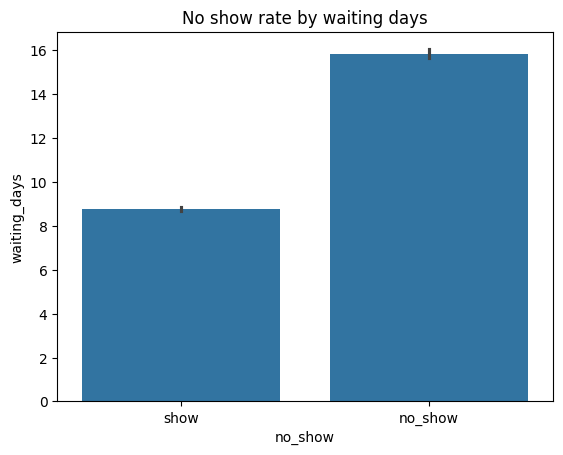


 No show rate - same day vs later
0         1
1         1
2         1
3         1
4         1
         ..
110522    0
110523    0
110524    0
110525    0
110526    0
Name: same_day_appointment, Length: 110522, dtype: int32
same_day_appointment
0    28.519018
1     4.646941
Name: no_show, dtype: float64


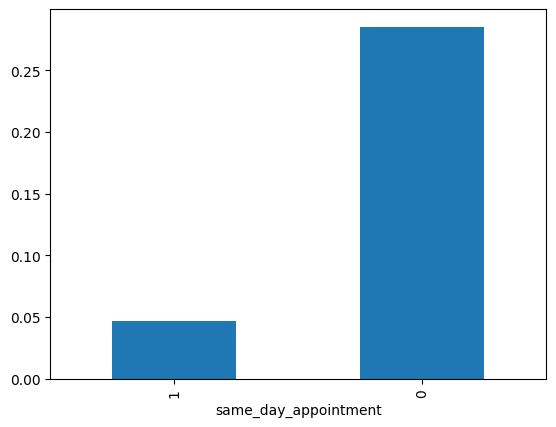

Weekday structure


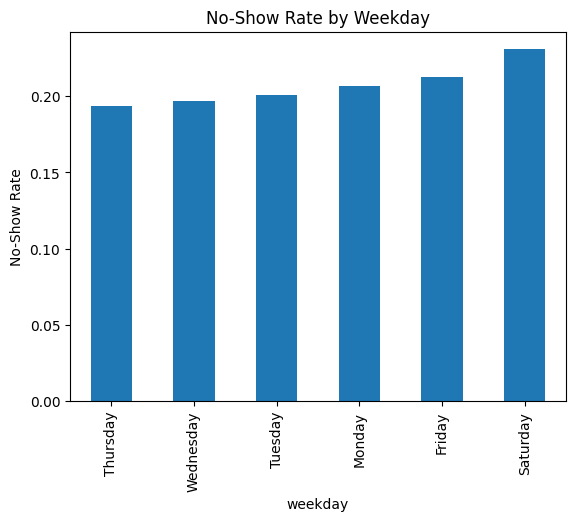

0         4
1         4
2         4
3         4
4         4
         ..
110522    1
110523    1
110524    1
110525    1
110526    1
Name: appointment_weekday, Length: 110522, dtype: int32
0         April
1         April
2         April
3         April
4         April
          ...  
110522     June
110523     June
110524     June
110525     June
110526     June
Name: appointment_month, Length: 110522, dtype: object


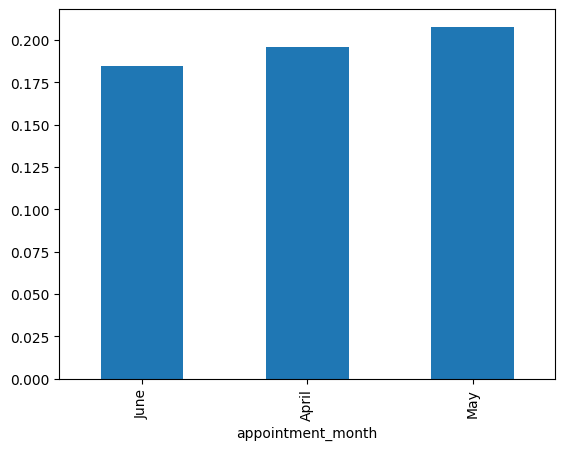

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Missing values in each column")
print(df.isnull().sum())
#Doing this because age_group got 3540
bins = [0,12,18,35,50,65,120]
labels = ['Child(0-12)', 'Teen(13-18)', 'Young Adult(19-35)',
          'Adult(36-50)', 'Senior(51-65)', 'Elderly(66+)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
print(df['age_group'].isnull().sum())


#Creating new features to be able to understand the no-shows better
df['appointment_weekday'] = df['appointment_day'].dt.dayofweek
df['appointment_month'] = df['appointment_day'].dt.month_name()
df['same_day_appointment'] = (df['appointment_day'].dt.date == df['scheduled_day'].dt.date).astype(int)

print("Waiting days")
print(df['waiting_days'].describe())

print("No show rate by waiting days")
print(df.groupby('waiting_days')['no_show'].mean().head(10)*100)
plt.xticks(ticks=[0,1], labels=['show', 'no_show'])
sns.barplot(x='no_show', y='waiting_days', data=df)
plt.title("No show rate by waiting days")
plt.xlabel("no_show")
plt.ylabel("waiting_days")
plt.show()

#Check same day appointment
print("\n No show rate - same day vs later")
print(df['same_day_appointment'])
print(df.groupby('same_day_appointment')['no_show'].mean()*100)
df.groupby('same_day_appointment')['no_show'].mean().sort_values().plot(kind='bar')
plt.show()

print("Weekday structure")
df.groupby('weekday')['no_show'].mean().sort_values().plot(kind='bar')
plt.title('No-Show Rate by Weekday')
plt.ylabel('No-Show Rate')
plt.show()

print(df['appointment_weekday'])
print(df['appointment_month'])
df.groupby('appointment_month')['no_show'].mean().sort_values().plot(kind='bar')
plt.show()

In [38]:
print(df['appointment_day'].describe())

count                           110522
mean     2016-05-19 00:58:34.724669696
min                2016-04-29 00:00:00
25%                2016-05-09 00:00:00
50%                2016-05-18 00:00:00
75%                2016-05-31 00:00:00
max                2016-06-08 00:00:00
Name: appointment_day, dtype: object


Step 6: Final EDA – Correlation & Key Insights

Correlation with No-Show(Strongest to Weakest): 
no_show         1.000
waiting_days    0.186
sms_received    0.127
scholarship     0.029
alcoholism     -0.000
handicap       -0.006
diabetes       -0.015
hypertension   -0.036
age            -0.060
Name: no_show, dtype: float64


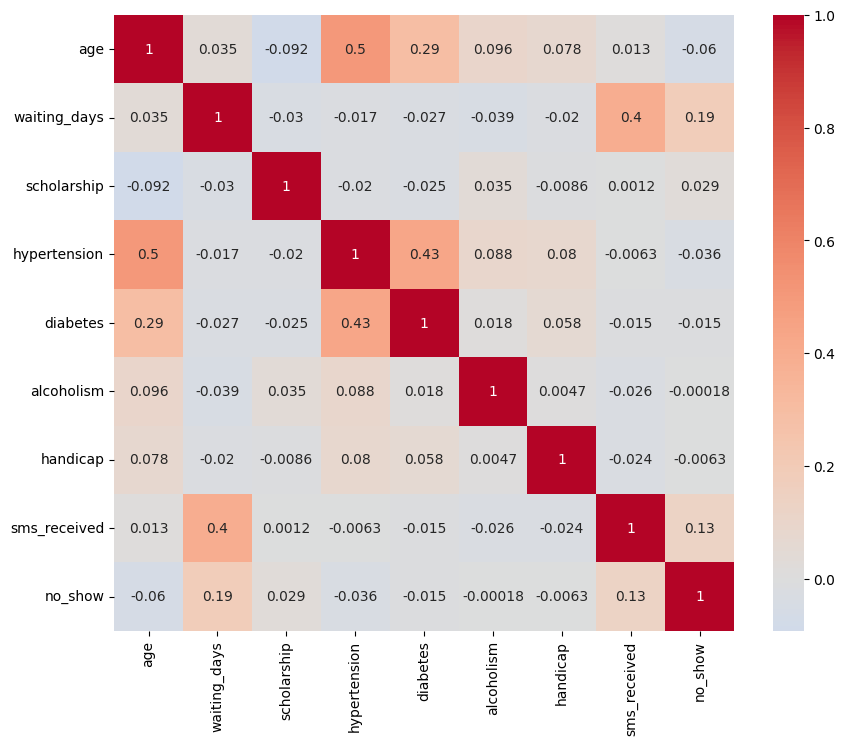

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['age','waiting_days','scholarship','hypertension','diabetes','alcoholism','handicap','sms_received','no_show']
#Correlation with the target(no_show)
corr_with_target = df[num_cols].corr()['no_show'].sort_values(ascending=False)

print("Correlation with No-Show(Strongest to Weakest): ")
print(corr_with_target.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.show()